# Implementing Linear Models and Multi-Layer Perceptrons from scratch and comparison 

In [1]:
# Install libraries in virtual lab environment
!pip install kagglehub
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import warnings
import kagglehub
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


/home/cloud/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Dataset Selection and Loading

In [3]:
# Step 1: Load your dataset
# Download latest version
path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")
print("Path to dataset files:", path)
data = pd.read_csv(path+"/updated_pollution_dataset.csv")

# Dataset information
dataset_name = "Air Quality and Pollution Assessment Dataset"
dataset_source = "Kaggle"
n_samples = 5000
n_features = 9
problem_type = "multiclass_classification"

# Problem statement
problem_statement = """
The goal is to predict the Air Quality Level (Good, Moderate, Poor, Hazardous)
based on environmental and demographic features such as pollutant concentrations,
weather conditions, and population density. Accurately classifying air quality
helps governments and environmental agencies issue timely warnings, implement
pollution control strategies, and protect public health.
"""

# Primary evaluation metric
primary_metric = "weighted_f1_score"

# Metric justification
metric_justification = """
Because the target classes (Good, Moderate, Poor, Hazardous) are imbalanced,
accuracy would give misleading results by favoring the majority class. The
weighted F1-score is more appropriate because it balances precision and recall
for each class while accounting for class frequencies, providing a fairer
evaluation of model performance across all air quality categories.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Path to dataset files: /home/cloud/.cache/kagglehub/datasets/mujtabamatin/air-quality-and-pollution-assessment/versions/2
Dataset: Air Quality and Pollution Assessment Dataset
Source: Kaggle
Samples: 5000, Features: 9
Problem Type: multiclass_classification
Primary Metric: weighted_f1_score


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [4]:
def stratified_split(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    """
    Stratified train-test-validation split of features and target matrices.

    Parameters:
        X : numpy array (N, D)
        y : numpy array (N,)
        train_size : float
        val_size : float
        test_size : float
        random_state : int

    Returns:
        X_train, X_val, X_test, y_train_onehot, y_val_onehot, y_test_onehot
    """

    np.random.seed(random_state)
    unique_classes = np.unique(y)

    train_indices = []
    val_indices = []
    test_indices = []

    for cls in unique_classes:
        # Select samples of this class
        class_idx = np.where(y == cls)[0]

        # Shuffle indices
        np.random.shuffle(class_idx)

        # Number of samples for train, test and validation
        n_total = len(class_idx)
        n_train = int(train_size * n_total)
        n_val = int(val_size * n_total)

        train_indices.extend(class_idx[:n_train])
        val_indices.extend(class_idx[n_train : n_train + n_val])
        test_indices.extend(class_idx[n_train + n_val:])

    # Convert lists of indices to numpy arrays
    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    test_indices = np.array(test_indices)

    # Shuffle the collected indices to mix samples from different classes
    np.random.shuffle(train_indices)
    np.random.shuffle(val_indices)
    np.random.shuffle(test_indices)

    # Extract data using collected indices
    X_train, y_train = X[train_indices], y[train_indices]
    X_val, y_val = X[val_indices], y[val_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    # One-hot encode
    y_train_onehot = to_one_hot(y_train)
    y_val_onehot = to_one_hot(y_val)
    y_test_onehot = to_one_hot(y_test)

    return X_train, X_val, X_test, y_train_onehot, y_val_onehot, y_test_onehot

In [5]:
def standard_scale(X):
    X = np.asarray(X, dtype=float)
    mean = np.mean(X, axis=0, keepdims=True)
    std = np.std(X, axis=0, keepdims=True)
    std[std == 0] = 1e-8
    X_scaled = (X - mean) / std
    return X_scaled

In [6]:
# Step 2: Preprocess your data

# Step 2.1. Separate features (X) and target (y)
print(f"Columns in the loaded dataset: {list(data.columns)}\n")

print(f"First 5 entries of features data:")
display(data.drop('Air Quality', axis=1).head())
print(f"\nFirst 5 corresponding entries of target data:")
print(data['Air Quality'][0:5])

X = standard_scale(data.drop('Air Quality', axis=1))
y = data['Air Quality']

print(f"\nFirst 5 entries of features data after scaling:")
print(X[0:5])

Columns in the loaded dataset: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality']

First 5 entries of features data:


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303



First 5 corresponding entries of target data:
0    Moderate
1    Moderate
2    Moderate
3        Good
4        Good
Name: Air Quality, dtype: object

First 5 entries of features data after scaling:
[[-0.03408041 -0.69071534 -0.60858932 -0.45045531 -0.84458126 -0.12072072
   0.40230264 -0.58865846 -1.16816284]
 [-0.25729505  0.34950721 -0.72670554 -0.65889176  0.49332918 -0.04664257
   0.25577499 -0.67174754  0.74359753]
 [-1.03110581  0.2927678   0.26709986  0.13097269 -0.22621929  0.38301072
   0.23745904 -0.89331843  0.79597453]
 [-0.43586677 -1.95159116 -0.57193257 -0.87464177 -1.45170029 -0.69853032
  -0.64170683  0.74076687  0.35077006]
 [-0.52515262  0.04059264 -0.53934878 -0.51993413 -0.50729292 -0.65408342
  -0.8981302   1.18390865 -1.27291684]]


In [7]:
# Step 2.2 Handle missing values if any
print(f"Basic information about the dataset:")
data.info()
print(f"Number of missing values in the dataset: {data.isnull().sum().sum()}")
print(f"Number of duplicated rows in the dataset: {data.duplicated().sum()}")

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB
Number of missing values in the dataset: 0
Number of duplicated rows in 

Since there is no duplicated rows or missing values in the dataset we dont have to implement any pre-processing step for it

In [8]:
def to_one_hot(y):
    shape = (y.size, int(np.max(y) + 1))
    rows = np.arange(y.size)
    one_hot = np.zeros(shape)
    one_hot[rows, y] = 1.
    return one_hot

In [9]:
# Step 2.3. Encode categorical variables
# We see that the target variable 'Air Quality' is categorical.
# So we will encode it to make sure the model can process it.

classes_mapping = {"Good": 0, "Moderate": 1, "Poor": 2, "Hazardous": 3}
print(f"Classes mapping: {classes_mapping}")
encoded_y = y.map(classes_mapping).astype(int)
print(f"First 5 entries of encoded target data:")
display(encoded_y.head().to_frame())
one_hot_y = to_one_hot(encoded_y.values)
print(f"First 5 entries of one-hot encoded target data:")
display(pd.DataFrame(one_hot_y, columns=[f"Class_{i}" for i in range(one_hot_y.shape[1])]).head())

Classes mapping: {'Good': 0, 'Moderate': 1, 'Poor': 2, 'Hazardous': 3}
First 5 entries of encoded target data:


,Air Quality
0,1
1,1
2,1
3,0
4,0


First 5 entries of one-hot encoded target data:


,Class_0,Class_1,Class_2,Class_3
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [10]:
# Step 3: Split the dataset
train_X, val_X, test_X, train_y, val_y, test_y = stratified_split(X, encoded_y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42)
print('✓ Dataset split into train, validation, and test sets successfully')

print("\nTrain set class distribution:")
print(pd.Series(np.argmax(train_y, axis=1)).value_counts())

print("\nValidation set class distribution:")
print(pd.Series(np.argmax(val_y, axis=1)).value_counts())

print("\nTest set class distribution:")
print(pd.Series(np.argmax(test_y, axis=1)).value_counts())

✓ Dataset split into train, validation, and test sets successfully

Train set class distribution:
0    1400
1    1050
2     700
3     350
Name: count, dtype: int64

Validation set class distribution:
0    300
1    225
2    150
3     75
Name: count, dtype: int64

Test set class distribution:
0    300
1    225
2    150
3     75
Name: count, dtype: int64


In [11]:
print(train_X, train_y)

[[ 0.65044449  1.59777428  2.27507554 ...  2.34379391 -0.61635482
   1.04476526]
 [ 0.26353911  1.02407578 -0.71448662 ...  1.04336108 -1.30876385
   0.35077006]
 [-1.7900356  -1.69311162 -0.60044338 ... -0.78823447  1.68244315
   0.48171255]
 ...
 [-0.67396239 -0.96180364 -0.03430013 ... -1.11792167  0.82385596
   0.21328044]
 [-0.77812922 -0.13592998 -0.72670554 ... -0.76991851  2.87338668
  -1.90144079]
 [ 1.60282696  0.76559623 -0.72263257 ... -0.84318234 -0.92101479
  -0.10752866]] [[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


In [12]:
n_samples, n_features = X.shape
classes = 4
weights = np.zeros([n_features, classes])
bias = 0
print(train_X.shape, weights.shape, train_y.shape[0])

(3500, 9) (9, 4) 3500


In [ ]:
train_samples = len(train_X)       # Number of training samples
val_samples = len(val_X)         # Number of validation samples
test_samples = len(test_X)        # Number of test samples

train_test_ratio = f"{train_samples/(train_samples + val_samples + test_samples):.2f}:{val_samples/(train_samples + val_samples + test_samples):.2f}:{test_samples/(train_samples + val_samples + test_samples):.2f}"  # e.g., 0.7:0.15:0.15 split

print(f"Train samples: {train_samples}")
print(f"Validation samples: {val_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio}")

Train samples: 3500
Validation samples: 750
Test samples: 750
Split ratio: 0.70:0.15:0.15


## Section 3: Baseline Model Implementation

In [14]:
# This is a softmax function which uses log-sum-exp trick to avoid overflow for large values of e^x
# In this case it is not necessary since the value of x would be small
# def softmax(z):
#     exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
#     return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    # y_pred: (N, K) predicted probabilities
    # y_true: (N, K) one-hot encoded true labels
    N = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred)) / N
    return loss

In [15]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.05, n_iterations=1000, reg_lambda=0.01, print_output=False, min_delta=1e-4):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.reg_lambda = reg_lambda
        self.training_loss_history = []
        self.validation_loss_history = []
        self.training_accuracy_list = []
        self.validation_accuracy_list = []
        self.patience = 5
        self.best_val_loss = np.inf
        self.print_output = print_output
        self.best_weights = None
        self.best_bias = None
        self.min_delta = min_delta

    def fit(self, X_train, y_train, X_val, y_val):
        X_train = np.asarray(X_train, dtype=np.float64)
        y_train = np.asarray(y_train, dtype=np.float64)
        n_samples, n_features = X_train.shape
        n_classes = y_train.shape[1]

        # TODO: Initialize parameters
        # self.weights = np.random.randn(n_features, n_classes) * 0.01
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros((1, n_classes))
        # self.print_output and print(X_train.shape, self.weights.shape, self.bias.shape)

        # TODO: Implement gradient descent loop
        for i in range(self.n_iterations):
            self.print_output and print("********************************************************")
            self.print_output and print(f"Iteration {i}:")
            self.print_output and print("************")
            # 1. Foward pass: Calculate y_pred

            softmax_score = np.dot(X_train, self.weights) + self.bias
            y_pred = softmax(softmax_score)

            # print("Shape of softmax score:", softmax_score.shape)
            # print("weights dtype:", self.weights.dtype)
            # print("bias dtype:", self.bias.dtype)
            # print("softmax_score dtype:", softmax_score.dtype)
            # print(y_pred.shape)
            # print(y_pred)

            #2. Compute loss: cross entropy loss function with regularization parameter

            loss = cross_entropy(y_pred, y_train) + (self.reg_lambda / (2 * n_samples)) * np.sum(np.square(self.weights))
            self.print_output and print(f"Training loss: {loss:.3f}")
            self.training_loss_history.append(loss)

            y_pred_classes = np.argmax(y_pred, axis=1)
            y_actual_classes = np.argmax(y_train, axis=1)
            training_accuracy = np.sum(y_pred_classes == y_actual_classes)/n_samples
            self.print_output and print("Number of correct classifications:" , np.sum(y_pred_classes == y_actual_classes))
            self.print_output and print("Number of incorrect classifications:" , np.sum(y_pred_classes != y_actual_classes))
            self.print_output and print(f"Training classification accuracy: {training_accuracy:.3f}")

            # 3. Compute gradients: dw = ..., db = ...

            # print("Shape of X transpose:", np.transpose(X).shape)
            # print("Shape of (y_pred - y):", (y_pred - y).shape)
            dw = (X_train.T @ (y_pred - y_train)) / n_samples + (self.reg_lambda * self.weights) / n_samples
            db = np.sum(y_pred - y_train, axis=0, keepdims=True) / n_samples
            # print("Shape of dw:", dw.shape)
            # print("Shape of db:", db.shape)
            # print("\nComputed gradients for W:", dw)
            # print("\nComputed gradients for b:", db)

            # 4. Update: self.weights -= self.lr * dw

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            if(self.evaluate_model(X_val, y_val)):
                self.print_output and (print("Model improved") if self.patience == 5 else print("Model performance Stagnated"))
                pass
            else:
                self.print_output and print("********************************************************")
                return self.return_best_model()
        self.print_output and print("********************************************************")
        return self.return_best_model()

    def evaluate_model(self, X_val, y_val):
        y_pred, y_pred_classes = self.predict(X_val)
        val_loss = cross_entropy(y_pred, y_val) + (self.reg_lambda / (2 * len(X_val))) * np.sum(np.square(self.weights))
        self.print_output and print(f"Validation loss: {val_loss:.3f}")
        self.validation_loss_history.append(val_loss)

        validation_accuracy = np.sum(y_pred_classes == np.argmax(y_val, axis=1))/len(X_val)
        self.print_output and print(f"Validation classification accuracy: {validation_accuracy:.3f}")
        self.validation_accuracy_list.append(validation_accuracy)

        if self.best_val_loss - val_loss > self.min_delta:
            self.best_val_loss = val_loss
            self.patience = 5
            self.best_weights = self.weights
            self.best_bias = self.bias
        else:
            self.patience -= 1
            # self.print_output and print(f"Patience: {self.patience}")

        if self.patience == 0:
            self.print_output and print("********************************************************")
            self.print_output and print("Model didn't improve\nEarly stopping triggered")
            return False
        return True

    def predict(self, X):
        softmax_value = np.dot(X, self.weights) + self.bias
        y_pred = softmax(softmax_value)
        y_pred_classes = np.argmax(y_pred, axis=1)
        return y_pred, y_pred_classes


    def return_best_model(self):
        self.weights = self.best_weights
        self.bias = self.best_bias
        return self

print("✓ Baseline model class defined")


✓ Baseline model class defined


In [16]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=1.9, n_iterations=1000, print_output=True, min_delta=3e-4)
baseline_model.fit(train_X, train_y, val_X, val_y)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(test_X)

baseline_training_time = time.time() - baseline_start_time

print("\n********************************************************")
print("Performance of the trained model in unseen test data:")
print("********************************************************")
baseline_predictions_probabilities = baseline_predictions[0]
baseline_predictions_classes = baseline_predictions[1]
actual_target_classes = np.argmax(test_y, axis=1)
test_loss = cross_entropy(baseline_predictions_probabilities, test_y)

print("Number of correct classifications:" , np.sum(baseline_predictions_classes == actual_target_classes))
print("Number of incorrect classifications:" , np.sum(baseline_predictions_classes != actual_target_classes))
print(f"Classification accuracy: {np.sum(baseline_predictions_classes == actual_target_classes)/len(baseline_predictions_classes):.3f}")
print(f"Test loss: {test_loss:.3f}")
print("********************************************************")

print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.training_loss_history[0]:.4f} to {baseline_model.training_loss_history[-1]:.4f}")

Training baseline model...
********************************************************
Iteration 0:
************
Training loss: 1.386
Number of correct classifications: 1400
Number of incorrect classifications: 2100
Training classification accuracy: 0.400
Validation loss: 0.672
Validation classification accuracy: 0.667
Model improved
********************************************************
Iteration 1:
************
Training loss: 0.671
Number of correct classifications: 2305
Number of incorrect classifications: 1195
Training classification accuracy: 0.659
Validation loss: 0.579
Validation classification accuracy: 0.800
Model improved
********************************************************
Iteration 2:
************
Training loss: 0.577
Number of correct classifications: 2766
Number of incorrect classifications: 734
Training classification accuracy: 0.790
Validation loss: 0.532
Validation classification accuracy: 0.816
Model improved
********************************************************

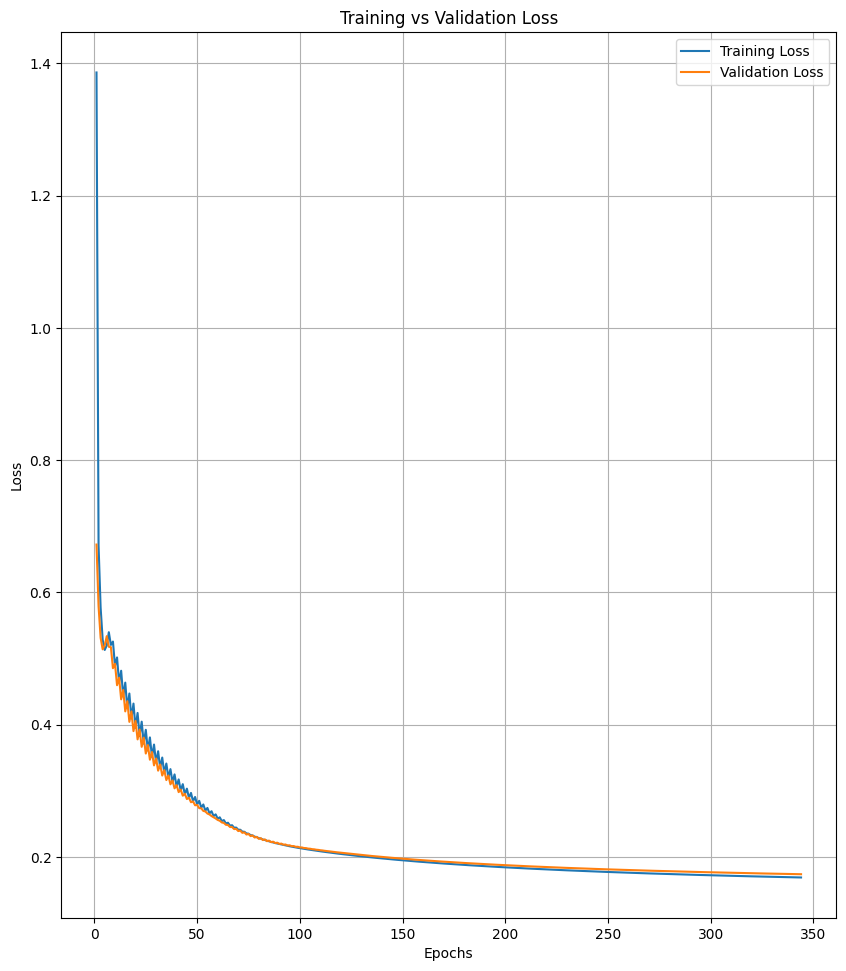

In [17]:
#Training vs validation loss graph
epochs = np.arange(1, len(baseline_model.training_loss_history) + 1)

plt.figure(figsize=(10, 11.5))
plt.plot(epochs, baseline_model.training_loss_history, label="Training Loss")
plt.plot(epochs, baseline_model.validation_loss_history, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

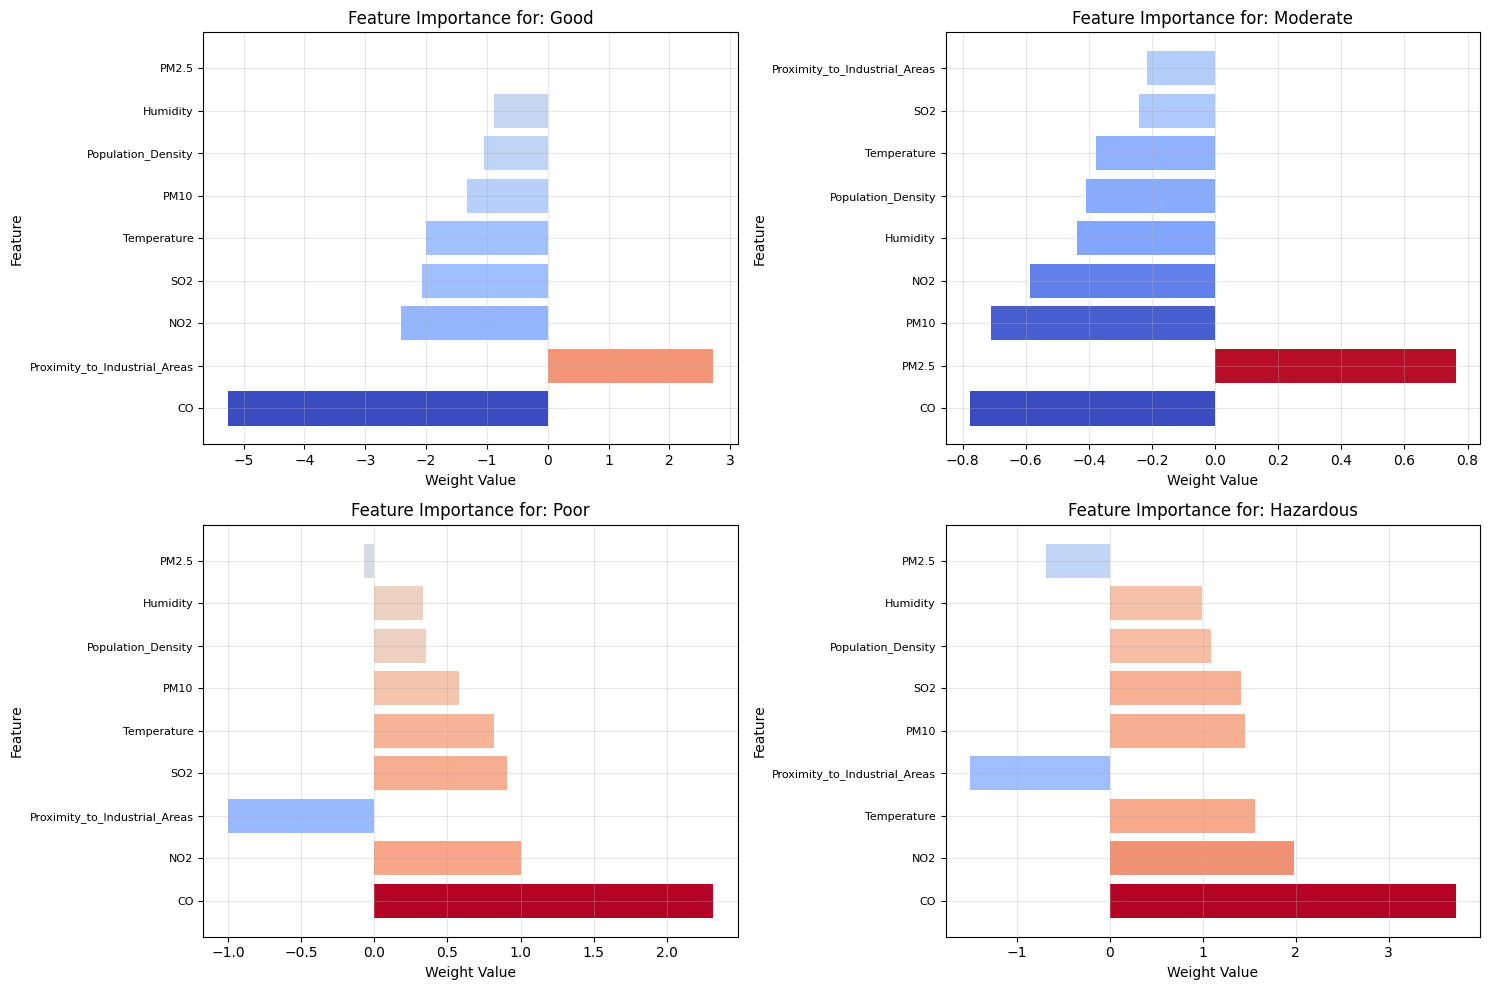

In [18]:
# Get feature names from the data DataFrame (assuming 'data' is available in the kernel)
feature_names = data.drop('Air Quality', axis=1).columns.tolist()

# Get class names from classes_mapping (assuming 'classes_mapping' is available)
class_names = list(classes_mapping.keys())

# Ensure baseline_model has been trained and has weights
if baseline_model and baseline_model.weights is not None:
    # Create a figure with 4 subplots for each class
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

    for i, class_name in enumerate(class_names):
        # Extract weights for the current class
        class_weights = baseline_model.weights[:, i]

        # Sort features by absolute weight for better visualization
        sorted_indices = np.argsort(np.abs(class_weights))[::-1]
        sorted_weights = class_weights[sorted_indices]
        sorted_feature_names = [feature_names[j] for j in sorted_indices]

        # Plot horizontal bar graph
        ax = axes[i]
        ax.barh(sorted_feature_names, sorted_weights, color=plt.cm.coolwarm(sorted_weights / np.max(np.abs(sorted_weights)) * 0.5 + 0.5))
        ax.set_title(f'Feature Importance for: {class_name}')
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Feature')
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Baseline model not trained or weights not available. Please run the training cell first.")

In [19]:
# Test effect of hyperparameter - learning rate

def model_performance(learning_rate):
  baseline_model = BaselineModel(learning_rate=learning_rate, n_iterations=1000, print_output=False)
  baseline_model.fit(train_X, train_y, val_X, val_y)
  baseline_predictions = baseline_model.predict(test_X)
  baseline_predictions_probabilities = baseline_predictions[0]
  baseline_predictions_classes = baseline_predictions[1]
  actual_target_classes = np.argmax(test_y, axis=1)
  test_loss = cross_entropy(baseline_predictions_probabilities, test_y) + (baseline_model.reg_lambda / (2 * len(test_X))) * np.sum(np.square(baseline_model.weights))
  return test_loss, np.sum(baseline_predictions_classes == actual_target_classes)/len(baseline_predictions_classes)

In [20]:
learning_rates = np.concatenate((np.arange(0.01, 1.5, 0.01), np.arange(1.5,5,0.1)))
# learning_rates = [1]
# print(len(learning_rates))
test_loss_list = []
test_accuracy_list = []
for learning_rate in learning_rates:
  test_loss, test_accuracy = model_performance(learning_rate)
  test_loss_list.append(test_loss)
  test_accuracy_list.append(test_accuracy)

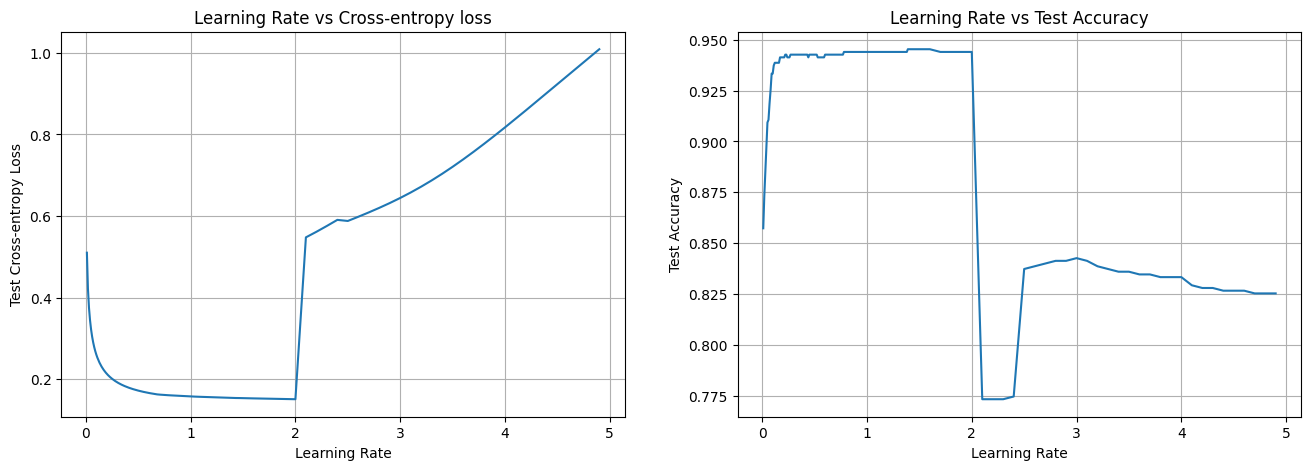

In [21]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(learning_rates, test_loss_list)
plt.xlabel("Learning Rate")
plt.ylabel("Test Cross-entropy Loss")
plt.title("Learning Rate vs Cross-entropy loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(learning_rates, test_accuracy_list)
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Learning Rate vs Test Accuracy")
plt.grid(True)
plt.show()

In [22]:
baseline_model = BaselineModel(learning_rate=1.9, n_iterations=1000, print_output=True, min_delta=3e-4)
baseline_model.fit(train_X, train_y, val_X, val_y)
baseline_predictions = baseline_model.predict(test_X)

********************************************************
Iteration 0:
************
Training loss: 1.386
Number of correct classifications: 1400
Number of incorrect classifications: 2100
Training classification accuracy: 0.400
Validation loss: 0.672
Validation classification accuracy: 0.667
Model improved
********************************************************
Iteration 1:
************
Training loss: 0.671
Number of correct classifications: 2305
Number of incorrect classifications: 1195
Training classification accuracy: 0.659
Validation loss: 0.579
Validation classification accuracy: 0.800
Model improved
********************************************************
Iteration 2:
************
Training loss: 0.577
Number of correct classifications: 2766
Number of incorrect classifications: 734
Training classification accuracy: 0.790
Validation loss: 0.532
Validation classification accuracy: 0.816
Model improved
********************************************************
Iteration 3:
************


## Observations

### 1. Early Stopping and Overfitting Behavior
The model was set to train for 1000 iterations, but the validation loss stopped improving after around **epoch 176**, which indicates the start of overfitting.  
Stopping training at this point prevents the model from memorizing noise and helps it generalize better.  
Early stopping also saves computation time by stopping once the model reaches its best performance.

---

### 2. Effect of Learning Rate (α) on Training Dynamics
Different learning rates were tested:

- **Small α (e.g., 0.01)** → slow convergence  
- **Large α (e.g., 3)** → unstable updates or divergence  

A learning rate of **α = 1.9** provided the most stable and consistent learning, allowing the loss to decrease smoothly without oscillation.

---

### 3. Improvement in Model Performance Over Epochs
The cross-entropy loss steadily decreased from around **1.4** at the beginning of training to below **0.2** near convergence.  
This shows that gradient descent successfully optimized the model parameters and that the softmax regression model learned to separate the four classes effectively.

---

### 4. Final Model Performance
After early stopping, the model achieved strong results on both validation and test sets:

- **Validation Loss:** 0.174  
- **Validation Accuracy:** 0.939
- **Test Loss:** 0.163  
- **Test Accuracy:** 0.943  

These results indicate that the model generalizes well to unseen data and avoids overfitting.

---

## Section 4: Multi-Layer Perceptron Implementation

In [23]:
class MLP:
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000, l2_lambda=0.01, dropout_rate=0.0, print_output=False):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.cache = {}
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        self.best_val_loss = float("inf")
        self.patience_max = 100
        self.patience = self.patience_max
        self.min_delta = 1e-6
        self.best_parameters = None
        self.validation_loss_history = []
        self.print_output = print_output
        self.training_loss_history = []
        self.validation_loss_history = []
        self.training_accuracy_list = []
        self.validation_accuracy_list = []

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            n_l = self.architecture[l]
            n_prev = self.architecture[l-1]
            self.parameters[f"W{l}"] = np.random.randn(n_l, n_prev) * np.sqrt(2.0 / n_prev)
            self.parameters[f"b{l}"] = np.zeros((n_l, 1))

    def _convert_to_class_indices(self, y):
        """Convert one-hot or class indices to class indices"""
        if len(y.shape) == 2:
            return np.argmax(y, axis=1)
        else:
            return y.astype(int)

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def softmax(self, Z):
        expZ = np.exp(Z)
        return expZ / np.sum(expZ, axis=0, keepdims=True)

    def forward_propagation(self, X):
        # Ensure X is transposed to (n_features, n_samples)
        self.cache["A0"] = X.T if X.shape[0] != self.architecture[0] else X
        L = len(self.architecture) - 1

        for l in range(1, L):
            W = self.parameters[f"W{l}"]
            b = self.parameters[f"b{l}"]
            Z = W @ self.cache[f"A{l-1}"] + b
            A = self.relu(Z)
            # Dropout
            if self.dropout_rate > 0:
                D = (np.random.rand(*A.shape) > self.dropout_rate).astype(float)
                A = (A * D) / (1 - self.dropout_rate)
                self.cache[f"D{l}"] = D
            self.cache[f"Z{l}"] = Z
            self.cache[f"A{l}"] = A
        W = self.parameters[f"W{L}"]
        b = self.parameters[f"b{L}"]
        ZL = W @ self.cache[f"A{L-1}"] + b
        AL = self.softmax(ZL)
        self.cache[f"Z{L}"] = ZL
        self.cache[f"A{L}"] = AL
        return AL

    def backward_propagation(self, y_true):
        grads = {}
        y_true = self._convert_to_class_indices(y_true)
        m = y_true.shape[0]
        L = len(self.architecture) - 1
        AL = self.cache[f"A{L}"]
        # Convert class indices to one-hot encoding
        one_hot = np.zeros((self.architecture[-1], m))
        one_hot[y_true, np.arange(m)] = 1
        dZ = AL - one_hot
        grads[f"dW{L}"] = (dZ @ self.cache[f"A{L-1}"].T) / m
        grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
        grads[f"dW{L}"] += (self.l2_lambda / m) * self.parameters[f"W{L}"]
        for l in reversed(range(1, L)):
            W_next = self.parameters[f"W{l+1}"]
            dZ_next = dZ
            Z = self.cache[f"Z{l}"]
            dA = W_next.T @ dZ_next
            if self.dropout_rate > 0:
                D = self.cache[f"D{l}"]
                dA = (dA * D) / (1 - self.dropout_rate)
            dZ = dA * self.relu_derivative(Z)
            grads[f"dW{l}"] = (dZ @ self.cache[f"A{l-1}"].T) / m
            grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
            grads[f"dW{l}"] += (self.l2_lambda / m) * self.parameters[f"W{l}"]
        return grads

    def update_parameters(self, grads):
        L = len(self.architecture) - 1
        for l in range(1, L+1):
            self.parameters[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.parameters[f"b{l}"] -= self.lr * grads[f"db{l}"]

    def compute_loss(self, y_pred, y_true):
        y_true = self._convert_to_class_indices(y_true)
        m = y_true.shape[0]
        one_hot = np.zeros((self.architecture[-1], m))
        one_hot[y_true, np.arange(m)] = 1
        ce_loss = -np.sum(one_hot * np.log(y_pred + 1e-12)) / m
        l2_loss = 0
        for l in range(1, len(self.architecture)):
            W = self.parameters[f"W{l}"]
            l2_loss += np.sum(W * W)
        l2_loss = (self.l2_lambda / (2 * m)) * l2_loss
        return ce_loss + l2_loss

    def fit(self, X_train, y_train, X_val, y_val):
        """
        X_train: (n_samples, n_features)
        y_train: (n_samples,) class indices OR (n_samples, n_classes) one-hot encoded
        X_val: (n_samples, n_features)
        y_val: (n_samples,) class indices OR (n_samples, n_classes) one-hot encoded
        """
        self.initialize_parameters()
        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X_train)
            loss = self.compute_loss(y_pred, y_train)
            self.training_loss_history.append(loss)
            y_train_labels = self._convert_to_class_indices(y_train)
            train_accuracy = np.mean(y_pred == y_train_labels)
            self.training_accuracy_list.append(train_accuracy)
            grads = self.backward_propagation(y_train)
            self.update_parameters(grads)
            if i % 100 == 0:
                print(f"Iteration {i} | Training Loss: {loss:.4f}")
            continue_training = self.evaluate_model(X_val, y_val)
            if not continue_training:
                print("Early stopping triggered — best model restored. Iterations completed:", i)
                break
        print(f"Iteration {i} | Training Loss: {loss:.4f} | Validation Loss: {self.validation_loss_history[-1]:.4f} | Validation Accuracy: {self.validation_accuracy_list[-1]:.4f}")
        return self

    def evaluate_model(self, X_val, y_val):
        y_prob = self.forward_propagation(X_val)
        y_pred = np.argmax(y_prob, axis=0)
        val_loss = self.compute_loss(y_prob, y_val)
        self.validation_loss_history.append(val_loss)
        y_val_labels = self._convert_to_class_indices(y_val)
        val_accuracy = np.mean(y_pred == y_val_labels)
        self.validation_accuracy_list.append(val_accuracy)
        self.print_output and print(f"Validation Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")
        if self.best_val_loss - val_loss > self.min_delta:
            self.best_val_loss = val_loss
            self.patience = self.patience_max
            self.best_parameters = {k: v.copy() for k, v in self.parameters.items()}
            self.print_output and print("Model improved")
        else:
            self.patience -= 1
            self.print_output and print("No improvement")
        if self.patience == 0:
            self.print_output and print("Patience exhausted — stopping.")
            self.parameters = {k: v.copy() for k, v in self.best_parameters.items()}
            return False
        return True

    def predict(self, X):
        y_prob = self.forward_propagation(X)
        y_pred = np.argmax(y_prob, axis=0) 
        return y_prob, y_pred

print("✓ MLP class defined")

✓ MLP class defined


In [24]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [9,16,8,4]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=1.24, n_iterations=1000, l2_lambda=0.01, print_output=False)
mlp_model.fit(train_X, np.argmax(train_y, axis=1), val_X, np.argmax(val_y, axis=1))
mlp_predictions = mlp_model.predict(test_X)

mlp_training_time = time.time() - mlp_start_time

print("\n********************************************************")
print("Performance of the trained model in unseen test data:")
print("********************************************************")
mlp_predictions_probabilities = mlp_predictions[0]
mlp_predictions_classes = mlp_predictions[1]
actual_target_classes = np.argmax(test_y, axis=1)
test_loss = cross_entropy(mlp_predictions_probabilities.T, test_y)

print("Number of correct classifications:" , np.sum(mlp_predictions_classes == actual_target_classes))
print("Number of incorrect classifications:" , np.sum(mlp_predictions_classes != actual_target_classes))
print(f"Classification accuracy: {np.sum(mlp_predictions_classes == actual_target_classes)/len(mlp_predictions_classes):.3f}")
print(f"Test cross-entropy loss: {test_loss:.3f}")
print("********************************************************")

print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.training_loss_history[0]:.4f} to {mlp_model.training_loss_history[-1]:.4f}")

Training MLP...
Iteration 0 | Training Loss: 2.1767
Iteration 100 | Training Loss: 0.2091
Iteration 200 | Training Loss: 0.1626
Iteration 300 | Training Loss: 0.1406
Iteration 400 | Training Loss: 0.1342
Iteration 500 | Training Loss: 0.1266
Iteration 600 | Training Loss: 0.1149
Early stopping triggered — best model restored. Iterations completed: 681
Iteration 681 | Training Loss: 0.0992 | Validation Loss: 0.1568 | Validation Accuracy: 0.9440

********************************************************
Performance of the trained model in unseen test data:
********************************************************
Number of correct classifications: 716
Number of incorrect classifications: 34
Classification accuracy: 0.955
Test cross-entropy loss: 0.142
********************************************************
✓ MLP training completed in 0.81s
✓ Loss decreased from 2.1767 to 0.0992


In [25]:
# Test effect of hyperparameter - learning rate for MLP

learning_rates_mlp = np.concatenate((np.arange(0.001,0.01,0.001), np.arange(0.01, 1.5, 0.01), np.arange(1.5,2.5,0.1)))
mlp_test_loss_list = []
mlp_test_accuracy_list = []

for learning_rate in learning_rates_mlp:
  print(f"\nTesting MLP with learning_rate={learning_rate}")
  mlp = MLP(architecture=mlp_architecture, learning_rate=learning_rate, n_iterations=1000, dropout_rate=0.0, print_output=False)
  mlp.fit(train_X, train_y, val_X, val_y)
  mlp_predictions = mlp.predict(test_X)
  mlp_pred_classes = mlp_predictions[1]
  actual_classes = np.argmax(test_y, axis=1)
  test_accuracy = np.sum(mlp_pred_classes == actual_classes) / len(actual_classes)
  mlp_test_loss_list.append(cross_entropy(mlp_predictions[0].T, test_y))
  mlp_test_accuracy_list.append(test_accuracy)
  print("********************************************************")

print("✓ MLP hyperparameter testing completed")


Testing MLP with learning_rate=0.001
Iteration 0 | Training Loss: 2.1767
Iteration 100 | Training Loss: 1.4691
Iteration 200 | Training Loss: 1.2346
Iteration 300 | Training Loss: 1.1223
Iteration 400 | Training Loss: 1.0466
Iteration 500 | Training Loss: 0.9872
Iteration 600 | Training Loss: 0.9382
Iteration 700 | Training Loss: 0.8968
Iteration 800 | Training Loss: 0.8614
Iteration 900 | Training Loss: 0.8304
Iteration 999 | Training Loss: 0.8036 | Validation Loss: 0.8185 | Validation Accuracy: 0.6987
********************************************************

Testing MLP with learning_rate=0.002
Iteration 0 | Training Loss: 2.1767
Iteration 100 | Training Loss: 1.2342
Iteration 200 | Training Loss: 1.0466
Iteration 300 | Training Loss: 0.9382
Iteration 400 | Training Loss: 0.8614
Iteration 500 | Training Loss: 0.8033
Iteration 600 | Training Loss: 0.7574
Iteration 700 | Training Loss: 0.7197
Iteration 800 | Training Loss: 0.6877
Iteration 900 | Training Loss: 0.6600
Iteration 999 | T

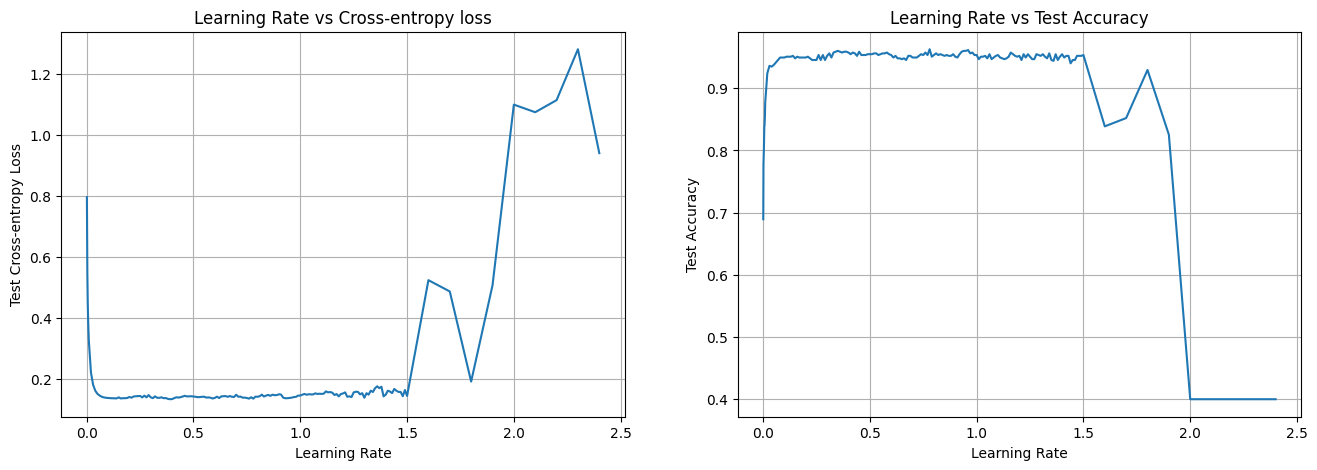

In [26]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(learning_rates_mlp, mlp_test_loss_list)
plt.xlabel("Learning Rate")
plt.ylabel("Test Cross-entropy Loss")
plt.title("Learning Rate vs Cross-entropy loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(learning_rates_mlp, mlp_test_accuracy_list)
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Learning Rate vs Test Accuracy")
plt.grid(True)
plt.show()

In [27]:
# Test effect of hyperparameter - dropout for MLP

dropout_mlp = np.arange(0, 0.6, 0.01)
mlp_test_loss_list = []
mlp_test_accuracy_list = []

for dropout in dropout_mlp:
  print(f"\nTesting MLP with drop-out={dropout}")
  mlp = MLP(architecture=mlp_architecture, learning_rate=1.24, n_iterations=1000, dropout_rate=dropout, print_output=False)
  mlp.fit(train_X, train_y, val_X, val_y)
  mlp_predictions = mlp.predict(test_X)
  mlp_pred_classes = mlp_predictions[1]
  actual_classes = np.argmax(test_y, axis=1)
  test_accuracy = np.sum(mlp_pred_classes == actual_classes) / len(actual_classes)
  mlp_test_loss_list.append(cross_entropy(mlp_predictions[0].T, test_y))
  mlp_test_accuracy_list.append(test_accuracy)
  print("********************************************************")

print("✓ MLP hyperparameter testing completed")


Testing MLP with drop-out=0.0
Iteration 0 | Training Loss: 2.1767
Iteration 100 | Training Loss: 0.2091
Iteration 200 | Training Loss: 0.1626
Iteration 300 | Training Loss: 0.1406
Iteration 400 | Training Loss: 0.1342
Iteration 500 | Training Loss: 0.1266
Iteration 600 | Training Loss: 0.1149
Early stopping triggered — best model restored. Iterations completed: 681
Iteration 681 | Training Loss: 0.0992 | Validation Loss: 0.1568 | Validation Accuracy: 0.9440
********************************************************

Testing MLP with drop-out=0.01
Iteration 0 | Training Loss: 2.1851
Iteration 100 | Training Loss: 0.2268
Iteration 200 | Training Loss: 0.1782
Iteration 300 | Training Loss: 0.1586
Iteration 400 | Training Loss: 0.1380
Iteration 500 | Training Loss: 0.1278
Early stopping triggered — best model restored. Iterations completed: 543
Iteration 543 | Training Loss: 0.1276 | Validation Loss: 0.1620 | Validation Accuracy: 0.9373
******************************************************

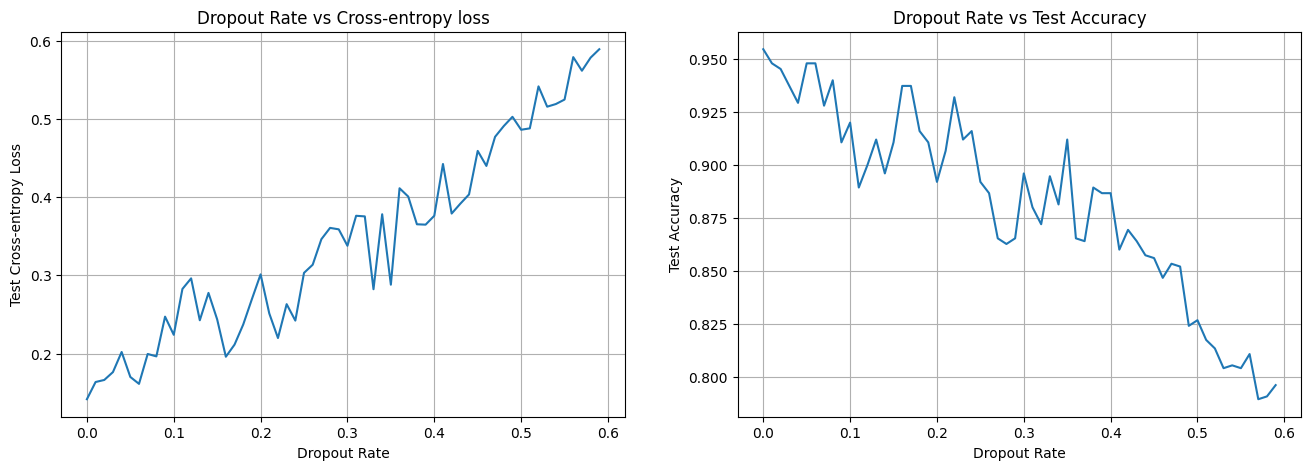

In [28]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(dropout_mlp, mlp_test_loss_list)
plt.xlabel("Dropout Rate")
plt.ylabel("Test Cross-entropy Loss")
plt.title("Dropout Rate vs Cross-entropy loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dropout_mlp, mlp_test_accuracy_list)
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.title("Dropout Rate vs Test Accuracy")
plt.grid(True)
plt.show()

In [29]:
mlp_architecture = [9,16,8,4]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=1.24, n_iterations=1000, l2_lambda=0.01, print_output=False)
mlp_model.fit(train_X, np.argmax(train_y, axis=1), val_X, np.argmax(val_y, axis=1))
mlp_predictions = mlp_model.predict(test_X)

Iteration 0 | Training Loss: 2.1767
Iteration 100 | Training Loss: 0.2091
Iteration 200 | Training Loss: 0.1626
Iteration 300 | Training Loss: 0.1406
Iteration 400 | Training Loss: 0.1342
Iteration 500 | Training Loss: 0.1266
Iteration 600 | Training Loss: 0.1149
Early stopping triggered — best model restored. Iterations completed: 681
Iteration 681 | Training Loss: 0.0992 | Validation Loss: 0.1568 | Validation Accuracy: 0.9440


## Observations

### 1. Early Stopping and Overfitting Behavior
The model was set to train for 1000 iterations, but the validation loss stopped improving after around **epoch 681**, which indicates the start of overfitting.  
Stopping training at this point prevents the model from memorizing noise and helps it generalize better.  
Early stopping also saves computation time by stopping once the model reaches its best performance.

---

### 2. Effect of Learning Rate (α) on Training Dynamics
Different learning rates were tested:

- **Small α (e.g., 0.01)** → slow convergence  
- **Large α (e.g., 3)** → unstable updates or divergence with exploding losses

A learning rate of **α = 1.24** provided the most stable and consistent learning, allowing the loss to decrease smoothly without oscillation.

---

### 3. Improvement in Model Performance Over Epochs
The cross-entropy loss steadily decreased from **2.1767** at the beginning of training to **0.0992** near convergence.  
This shows that gradient descent successfully optimized the model parameters and that the softmax regression model learned to separate the four classes effectively.

---

### 4. Effect of Dropout rate on Training Dynamics
* Multiple dropout rates were tested, but the model consistently performed best without dropout. As the dropout rate increased, the accuracy steadily declined.
* This is because the network has relatively few neurons, making it a simple model. Applying dropout in such a small architecture removes too many active units during training, reducing the model’s ability to learn meaningful patterns.
* In this case, dropout is unnecessary and only harms performance rather than preventing overfitting.

---

### 5. Final Model Performance
After early stopping, the model achieved strong results on both validation and test sets:

- **Validation Loss:** 0.1568  
- **Validation Accuracy:** 0.944
- **Test Loss:** 0.142  
- **Test Accuracy:** 0.955  

These results indicate that the model generalizes well to unseen data and avoids overfitting.

---

## Section 5: Evaluation and Metrics

In [30]:
def classification_accuracy_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(y_true)
    support = np.array([(y_true == c).sum() for c in classes], dtype=float)
    correct = (y_true == y_pred).sum()
    accuracy = correct / len(y_true)
    tp = np.array([( (y_true == c) & (y_pred == c) ).sum() for c in classes], dtype=float)
    fp = np.array([( (y_true != c) & (y_pred == c) ).sum() for c in classes], dtype=float)
    fn = np.array([( (y_true == c) & (y_pred != c) ).sum() for c in classes], dtype=float)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall    = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall,
                   precision + recall,
                   out=np.zeros_like(precision),
                   where=(precision + recall) != 0)
    weighted_f1 = np.sum(f1 * support) / np.sum(support)
    return {"accuracy" : accuracy, "precision" : precision, "recall" : recall, "weighted f1" :weighted_f1, "f1_score": f1}

In [31]:
def calculate_metrics(y_true, y_pred, problem_type):
    metrics = {}

    if problem_type == "regression":
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        return classification_accuracy_metrics(y_true, y_pred)
    else:
        pass
    
    return metrics

y_true_labels = np.argmax(test_y, axis=1)
baseline_metrics = calculate_metrics(y_true_labels, baseline_predictions[1], problem_type)
mlp_metrics = calculate_metrics(y_true_labels, mlp_predictions[1], problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'accuracy': np.float64(0.9426666666666667), 'precision': array([0.99335548, 0.95154185, 0.84375   , 0.91935484]), 'recall': array([0.99666667, 0.96      , 0.9       , 0.76      ]), 'weighted f1': np.float64(0.9421342187230494), 'f1_score': array([0.99500832, 0.95575221, 0.87096774, 0.83211679])}

MLP Model Performance:
{'accuracy': np.float64(0.9546666666666667), 'precision': array([0.99666667, 0.96444444, 0.89864865, 0.87012987]), 'recall': array([0.99666667, 0.96444444, 0.88666667, 0.89333333]), 'weighted f1': np.float64(0.954681384669728), 'f1_score': array([0.99666667, 0.96444444, 0.89261745, 0.88157895])}


## Section 6: Visualization

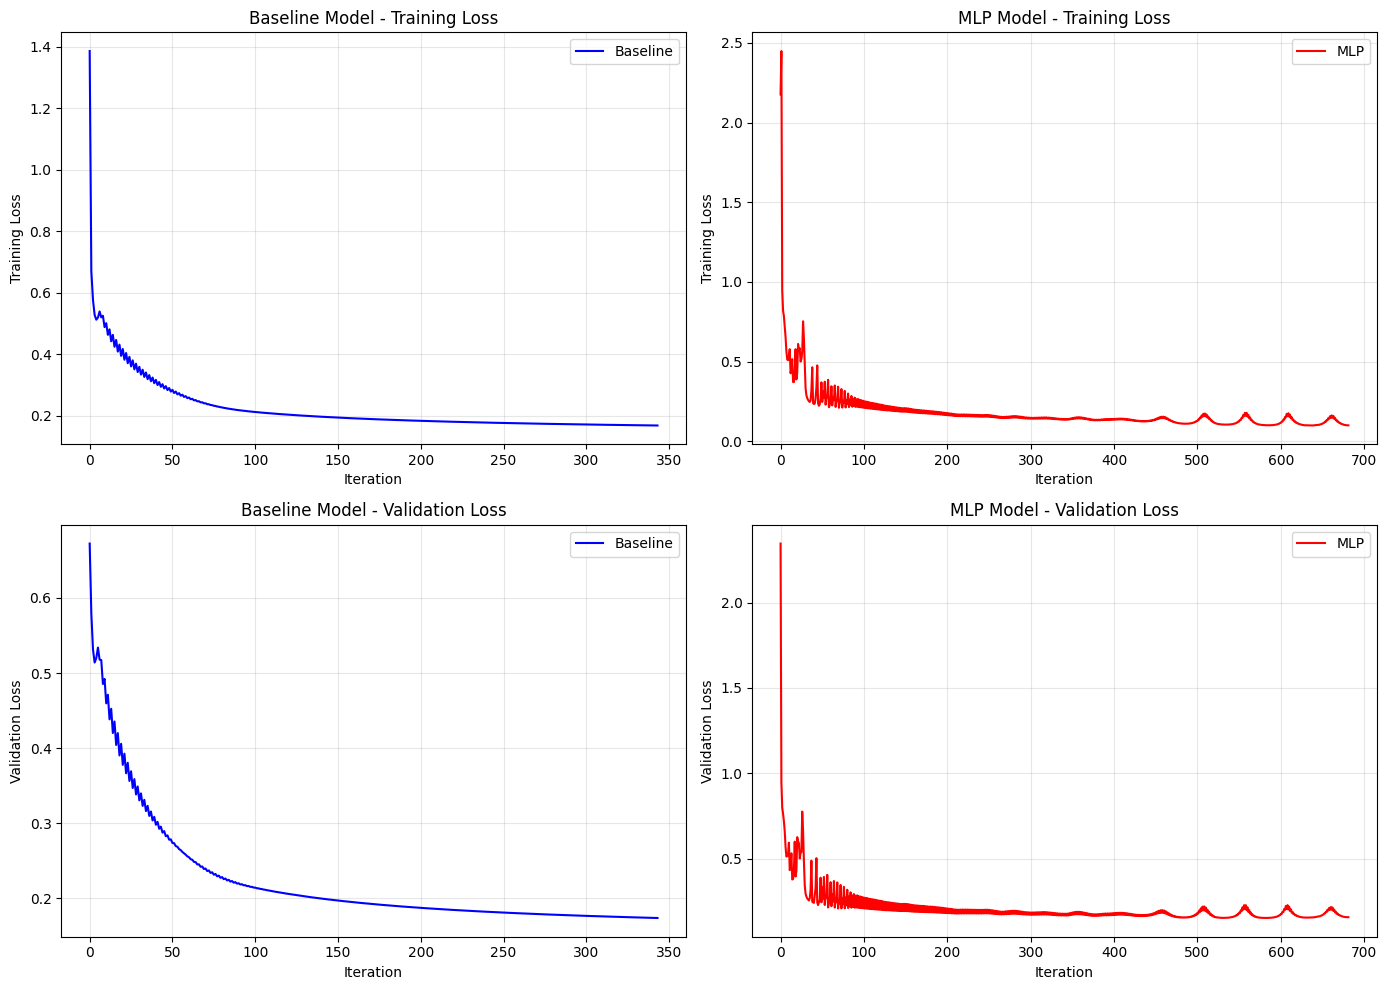

In [32]:
# 1. Training and Validation loss curves
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(baseline_model.training_loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(mlp_model.training_loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(baseline_model.validation_loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Validation Loss')
plt.title('Baseline Model - Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(mlp_model.validation_loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Validation Loss')
plt.title('MLP Model - Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

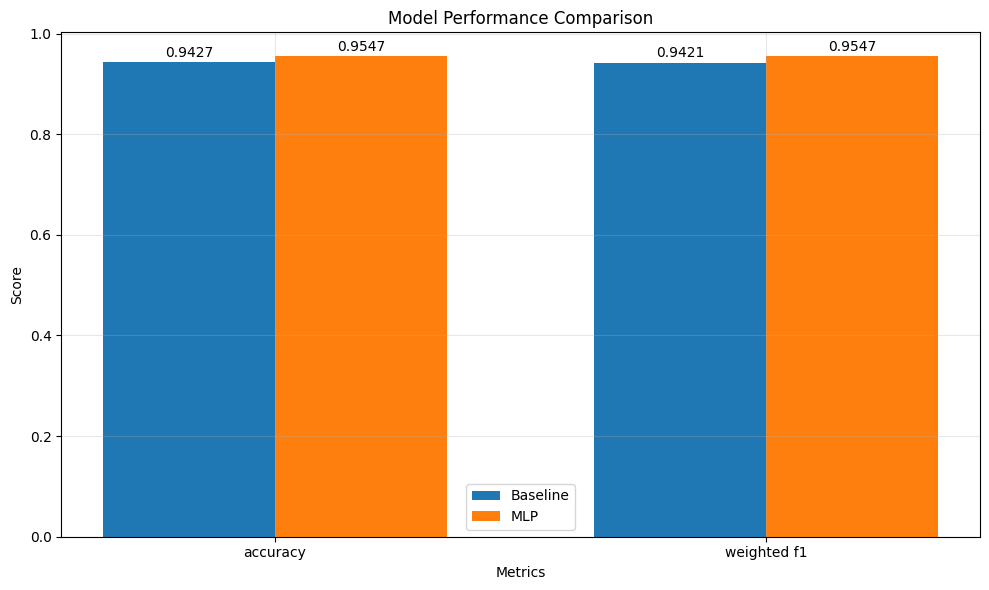

In [33]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metrics = ['accuracy', 'weighted f1']
baseline_scores = [baseline_metrics[m] for m in metrics]
mlp_scores = [mlp_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35
bars1 = plt.bar(x - width/2, baseline_scores, width, label='Baseline')
bars2 = plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

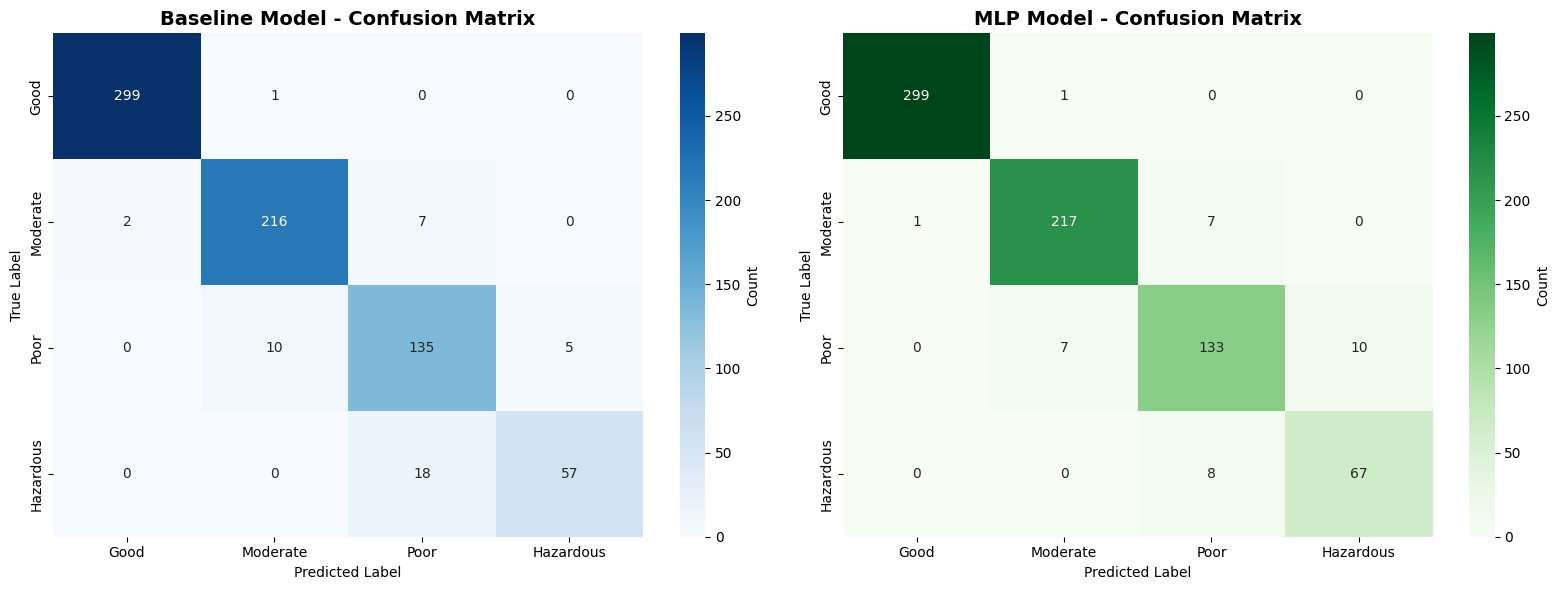

In [34]:
def compute_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# Get predictions from both models
baseline_pred = baseline_predictions[1]
mlp_pred = mlp_predictions[1]
actual = np.argmax(test_y, axis=1)

# Create inverse mapping for class labels
inverse_classes_mapping = {v: k for k, v in classes_mapping.items()}
class_labels = [inverse_classes_mapping[i] for i in range(4)]

# 3. Confusion Matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_baseline = compute_confusion_matrix(actual, baseline_pred, 4)

# Plot
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Count'})
axes[0].set_title('Baseline Model - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# MLP confusion matrix
cm_mlp = compute_confusion_matrix(actual, mlp_pred, 4)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Count'})
axes[1].set_title('MLP Model - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

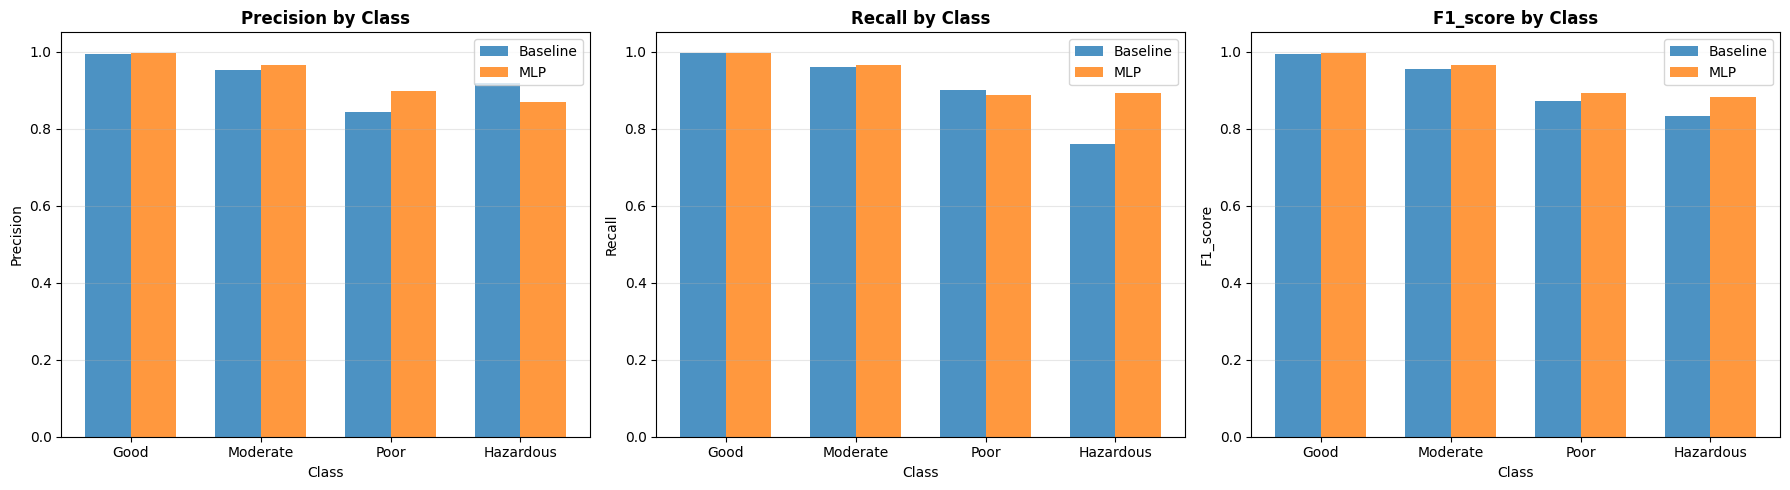

In [35]:

# 4. Per-class performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['precision', 'recall', 'f1_score']

for idx, metric in enumerate(metrics_to_plot):
    baseline_scores = [baseline_metrics[metric][i] for i in range(4)]
    mlp_scores = [mlp_metrics[metric][i] for i in range(4)]
    
    x = np.arange(len(class_labels))
    width = 0.35
    
    axes[idx].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8)
    axes[idx].bar(x + width/2, mlp_scores, width, label='MLP', alpha=0.8)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel(metric.capitalize())
    axes[idx].set_title(f'{metric.capitalize()} by Class', fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(class_labels)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()